In [2]:
# ==========================================
# Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader

In [3]:
# ==========================================
# 1.Load the data set
# ==========================================
df = pd.read_csv("LT.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4184 entries, 0 to 4183
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                4184 non-null   str    
 1   Symbol              4184 non-null   str    
 2   Series              4184 non-null   str    
 3   Prev Close          4184 non-null   float64
 4   Open                4184 non-null   float64
 5   High                4184 non-null   float64
 6   Low                 4184 non-null   float64
 7   Last                4184 non-null   float64
 8   Close               4184 non-null   float64
 9   VWAP                4184 non-null   float64
 10  Volume              4184 non-null   int64  
 11  Turnover            4184 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4184 non-null   int64  
 14  %Deliverble         4184 non-null   float64
dtypes: float64(10), int64(2), str(3)
memory usage: 547.6 KB


In [5]:
#fix date , sorting and cleaning
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.drop_duplicates().dropna()

# selecting needed columns
cols = ['Prev Close','Open','High','Low','Last','Close',
        'VWAP', 'Volume', 'Turnover', 'Trades','Deliverable Volume']
data =df[cols].values
dates =df['Date'].values

In [6]:
# ==========================================
# 2. Train/Test Split & Normalization
# ==========================================
split=int(len(data) * 0.8)
train_data=data[:split]
test_data=data[split:]

scaler=StandardScaler()
train_scaled=scaler.fit_transform(train_data)
test_scaled=scaler.transform(test_data)
scaled_data =np.vstack((train_scaled,test_scaled))

In [7]:
# ==========================================
# 3.Time-Series Chunking
# ==========================================
X,y,target_dates = [],[],[]
for i in range(len(scaled_data)-20-5+1):
    X.append(scaled_data[i:i+20])
    y.append(scaled_data[i+20:i+20+5])
    target_dates.append(dates[i+20:i+20+5])

X=np.array(X)
y=np.array(y)

# split again
seq_split=int(len(X)*0.8)
X_train,X_test =X[:seq_split],X[seq_split:]
y_train,y_test =y[:seq_split],y[seq_split:]
dates_test = target_dates[seq_split:]

#loaders
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)) , batch_size=32 , shuffle=False)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)) , batch_size=32 , shuffle=False)

In [8]:
# ==========================================
# 4. Defining LSTM Model
# ==========================================
class TimeSeriesLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        # 11 features in , 128 hidden size, 2 layers
        self.lstm=nn.LSTM(11,128,2,batch_first=True,dropout=0.3)
        #Output gives 5 days x 11 features
        self.fc=nn.Linear(128,55)

    def forward(self,x):
        out, _ = self.lstm(x)
        # Take the last time step output
        out = self.fc(out[:,-1,:]) 
        # Reshape output to 5 days and 11 features
        return out.view(-1,5,11)

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=TimeSeriesLSTM().to(device)
optimizer=torch.optim.Adam(model.parameters(), lr=0.0005)
loss_fn=nn.MSELoss()

In [9]:
# ==========================================
# 5. Training Loop
# ==========================================
for epoch in range(60):
    model.train()
    for batch_X,batch_y in train_loader:
        batch_X,batch_y=batch_X.to(device),batch_y.to(device)
        
        optimizer.zero_grad()
        preds = model(batch_X)
        loss = loss_fn(preds, batch_y)
        loss.backward()
        optimizer.step()
        
    if epoch % 10==0:
        print(f"Epoch {epoch} finished. Loss: {loss.item():.4f} ")

Epoch 0 finished. Loss: 0.1597 
Epoch 10 finished. Loss: 0.1441 
Epoch 20 finished. Loss: 0.1485 
Epoch 30 finished. Loss: 0.1520 
Epoch 40 finished. Loss: 0.1504 
Epoch 50 finished. Loss: 0.1419 


In [13]:
# ==========================================
# 6.Evaluation and Metrics
# ==========================================
model.eval()
test_preds=[]
test_actuals=[]

with torch.no_grad():
    for batch_X,batch_y in test_loader:
        preds = model(batch_X.to(device)).cpu().numpy()
        test_preds.append(preds)
        test_actuals.append(batch_y.numpy())

# combine all batches
test_preds =np.concatenate(test_preds,axis=0)
test_actuals =np.concatenate(test_actuals,axis=0)

# reshape to (-1, 11) for inverse scaling
test_preds =test_preds.reshape(-1,11)
test_actuals =test_actuals.reshape(-1,11)

# inverse transform (back to original values)
inv_preds =scaler.inverse_transform(test_preds)
inv_actuals =scaler.inverse_transform(test_actuals)

feature_names=['Prev Close','Open','High','Low','Last','Close',
               'VWAP','Volume','Turnover','Trades','Deliverable Volume']

print("\n--- Overall Model Performance ---")

overall_mse=mean_squared_error(inv_actuals,inv_preds)
overall_rmse=np.sqrt(overall_mse)
overall_mae=mean_absolute_error(inv_actuals,inv_preds)
overall_mape=np.mean(np.abs((inv_actuals - inv_preds)/(inv_actuals+1e-8)))*100
overall_accuracy = 100 - overall_mape

print(f"Overall MSE: {overall_mse:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")
print(f"Overall MAE: {overall_mae:.4f}")
print(f"Overall MAPE: {overall_mape:.2f}%")
print(f"Overall Accuracy: {overall_accuracy:.2f}%")

print("\n" + "="*40)
print("Performance Metrics (All Features)")
print("="*40)
for i in range(11):
    true_vals = inv_actuals[:, i]
    pred_vals = inv_preds[:, i]

    mse=mean_squared_error(true_vals, pred_vals)
    rmse=np.sqrt(mse)
    mae=mean_absolute_error(true_vals, pred_vals)
    mape=np.mean(np.abs((true_vals - pred_vals)/(true_vals + 1e-8))) * 100
    accuracy=100 - mape

    print(f"\nFeature: {feature_names[i]}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Accuracy: {accuracy:.2f}%")


--- Overall Model Performance ---
Overall MSE: 12065063151471309119809388544.0000
Overall RMSE: 109841081346968.3125
Overall MAE: 22069578301440.0000
Overall MAPE: 17.14%
Overall Accuracy: 82.86%

Performance Metrics (All Features)

Feature: Prev Close
MSE: 3136.6218
RMSE: 56.0056
MAE: 42.0473
MAPE: 3.81%
Accuracy: 96.19%

Feature: Open
MSE: 3325.1655
RMSE: 57.6642
MAE: 42.6315
MAPE: 3.82%
Accuracy: 96.18%

Feature: High
MSE: 3625.9277
RMSE: 60.2157
MAE: 44.8970
MAPE: 3.90%
Accuracy: 96.10%

Feature: Low
MSE: 3870.9939
RMSE: 62.2173
MAE: 43.9069
MAPE: 4.00%
Accuracy: 96.00%

Feature: Last
MSE: 3682.0710
RMSE: 60.6801
MAE: 45.4030
MAPE: 4.05%
Accuracy: 95.95%

Feature: Close
MSE: 3820.8374
RMSE: 61.8129
MAE: 46.3909
MAPE: 4.14%
Accuracy: 95.86%

Feature: VWAP
MSE: 3620.0601
RMSE: 60.1669
MAE: 44.1392
MAPE: 3.93%
Accuracy: 96.07%

Feature: Volume
MSE: 10470275678208.0000
RMSE: 3235780.5362
MAE: 2153550.7500
MAPE: 41.80%
Accuracy: 58.20%

Feature: Turnover
MSE: 13271575369576543618846844

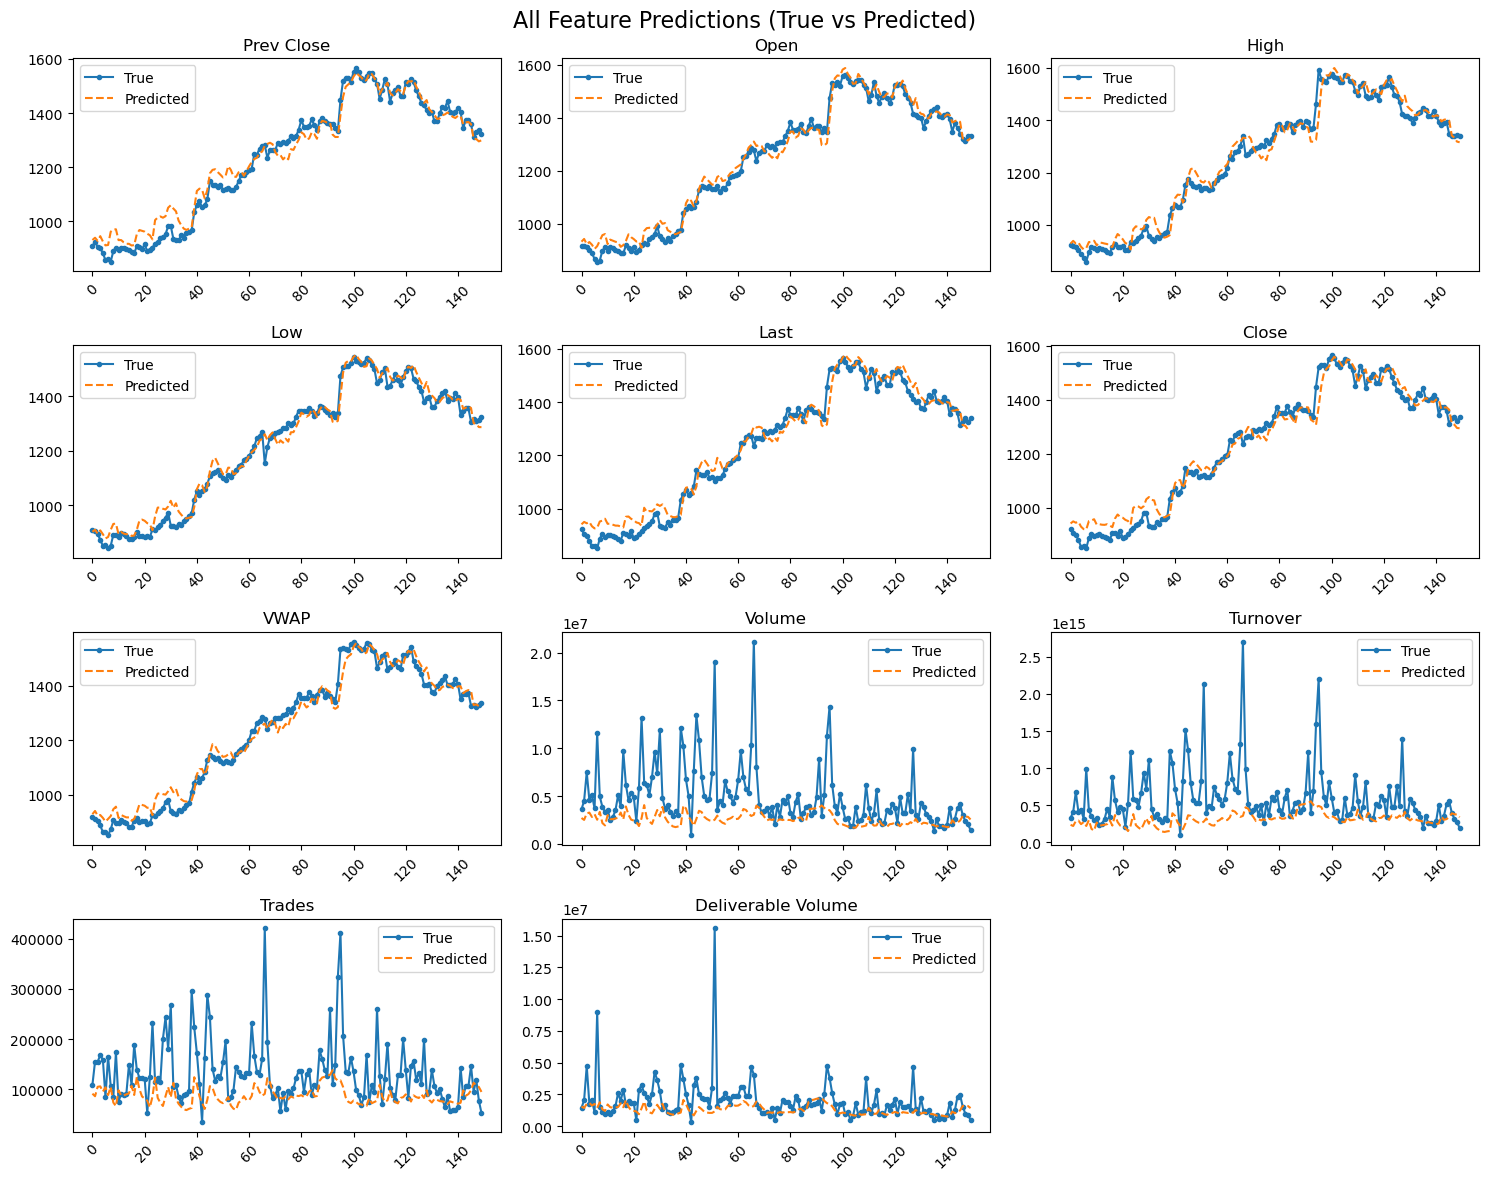

In [12]:
# ==========================================
# 7. Plotting True vs Predicted
# ==========================================
# reshape back to sequence form
inv_preds_seq=inv_preds.reshape(-1,5,11)
inv_actuals_seq=inv_actuals.reshape(-1,5,11)

# create 11 subplots (4 rows x 3 columns = 12 slots)
fig,axes=plt.subplots(4,3,figsize=(15,12))
axes=axes.flatten()

for i in range(11):
    true_vals=inv_actuals_seq[:,0,i]
    pred_vals=inv_preds_seq[:,0,i]
    
    axes[i].plot(true_vals[-150:],label="True",marker='.')
    axes[i].plot(pred_vals[-150:],label="Predicted",linestyle='--')
    
    axes[i].set_title(feature_names[i])
    axes[i].tick_params(axis='x',rotation=45)
    axes[i].legend()
# remove extra empty subplot (12th box)
fig.delaxes(axes[11])

fig.suptitle("All Feature Predictions (True vs Predicted)", fontsize=16)
plt.tight_layout()
plt.show()